# Forecasting daily online retail sales

Predict the next day's **net merchandise sales** for the [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) extract (Daqing Chen, Sai Laing Sain, and Kun Guo, 2012; [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)).

The series is one UK gift retailer, 1 December 2010 through 8 December 2011. Same-day sales are the target. Every sales feature comes from earlier days. Models are compared on a later time window, not on a random split.

This notebook calls `src/forecast.py`, the same code as `train.py`. Run it from the repository root.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.forecast import (
    DISPLAY_NAMES,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    add_features,
    format_metrics_table,
    load_daily_revenue,
    run_evaluation,
)

daily = load_daily_revenue(ROOT / "data" / "daily_revenue.csv")
print(f"{len(daily)} days, {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"Total net sales: £{daily['revenue'].sum():,.2f}")
print(f"Zero-sales days: {int((daily['revenue'] == 0).sum())}")
daily.head()


373 days, 2010-12-01 to 2011-12-08
Total net sales: £9,762,760.55
Zero-sales days: 69


,date,revenue
0,2010-12-01,57328.60
1,2010-12-02,46174.28
2,2010-12-03,43510.73
3,2010-12-04,0.00
4,2010-12-05,30957.28


## What a row is

`scripts/build_daily_revenue.py` builds this file from the UCI workbook. A row is one calendar day. `revenue` is the sum of `Quantity * UnitPrice` on product lines (stock code starts with a digit, unit price above zero). Negative quantities reduce the day. The workbook's last timestamp is 12:50 on 9 December 2011, so that partial day is excluded. Days with no kept invoices are 0, which is every Saturday here.


In [2]:
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_weekday = (
    daily.groupby(daily["date"].dt.dayofweek)["revenue"]
    .agg(mean="mean", median="median", days="size")
    .rename(index=dict(enumerate(weekday_names)))
)
by_weekday.round(2)


,mean,median,days
date,,,
Monday,30669.33,26894.73,53
Tuesday,37140.65,31990.84,53
Wednesday,32273.84,27480.23,54
Thursday,38597.52,35382.08,54
Friday,29131.30,26058.22,53
Saturday,0.00,0.00,53
Sunday,15053.19,11922.24,53


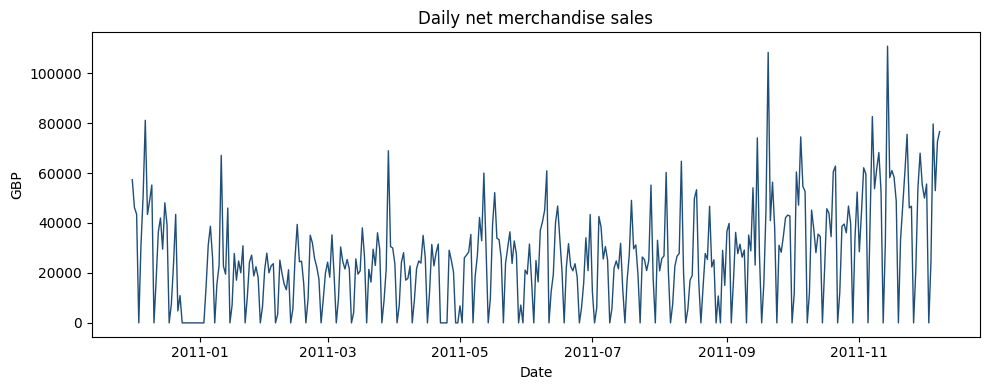

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily["date"], daily["revenue"], color="#1f4e79", linewidth=1)
ax.set_title("Daily net merchandise sales")
ax.set_ylabel("GBP")
ax.set_xlabel("Date")
fig.tight_layout()
plt.show()


## Features

The model for day *t* may use sales from before *t*, and the weekday of *t*. It may not use sales from *t*. Rolling means are computed after `shift(1)`, so the window ends yesterday.

`lag_7` is also the seasonal naive forecast: predict today with last week's same weekday.


In [4]:
featured = add_features(daily)
previous_day = featured["revenue"].shift(1)
lag_matches = featured["lag_1"].iloc[1:].reset_index(drop=True).equals(
    featured["revenue"].iloc[:-1].reset_index(drop=True)
)
print(f"Modeled days: {len(featured)} ({featured['date'].min().date()} to {featured['date'].max().date()})")
print(f"lag_1 equals the previous day's sales: {lag_matches}")
print(f"Target column is not a feature: {TARGET_COLUMN not in FEATURE_COLUMNS}")

planted = daily.copy()
planted.loc[planted.index[-1], "revenue"] = -1.0
replanned = add_features(planted)
features_unchanged = featured[FEATURE_COLUMNS].equals(replanned[FEATURE_COLUMNS])
print(f"Replacing the last day's sales leaves every feature row unchanged: {features_unchanged}")
featured[["date", "revenue", *FEATURE_COLUMNS]].head(3)


Modeled days: 345 (2010-12-29 to 2011-12-08)
lag_1 equals the previous day's sales: True
Target column is not a feature: True
Replacing the last day's sales leaves every feature row unchanged: True


,date,revenue,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_28,day_of_week
0,2010-12-29,0.0,0.0,4791.17,29517.91,2248.265714,27152.063571,2
1,2010-12-30,0.0,0.0,10946.69,48088.35,1563.812857,25104.613571,3
2,2010-12-31,0.0,0.0,0.00,39402.21,0.000000,23455.532143,4


## Split and models

After the 28-day warmup, the rows are cut in time:

- earliest 60% trains the models scored on validation
- next 20% is validation, used only to pick the lowest MAE
- last 20% is the test window

Test scores come from models refit on everything before the test window. The seasonal naive forecast does not fit coefficients. Ridge scales the lag features inside the pipeline, so the scaler never sees the test rows. The random forest uses 300 trees, depth 6, and a minimum leaf of 5 (`random_state=0`).


In [5]:
result = run_evaluation(featured)
for name, period in result["periods"].items():
    print(f"{name:12} {period['rows']:3} days  {period['start']} to {period['end']}")

print("\nValidation (selection)")
print(format_metrics_table(result["validation"]))
print("\nTest (held out)")
print(format_metrics_table(result["test"]))

selected = result["selected_model"]
test_scores = result["test"]
naive_mae = test_scores["seasonal_naive"]["mae"]
selected_mae = test_scores[selected]["mae"]
gap = naive_mae - selected_mae
print(
    f"\nValidation selected {DISPLAY_NAMES[selected]}. "
    f"On the test window its MAE is £{selected_mae:,.2f}, "
    f"which is £{gap:,.2f} lower than the seasonal naive MAE of £{naive_mae:,.2f}."
)
print(
    f"Ridge test MAE is £{test_scores['ridge']['mae']:,.2f}. "
    "It beat the naive forecast on validation and lost to it on this later window."
)


train        207 days  2010-12-29 to 2011-07-23
validation    69 days  2011-07-24 to 2011-09-30
test          69 days  2011-10-01 to 2011-12-08

Validation (selection)
| Model | MAE (GBP) | RMSE (GBP) | R² |
| --- | ---: | ---: | ---: |
| Seasonal naive | 11,593.10 | 17,978.33 | 0.1667 |
| Ridge | 11,007.89 | 16,006.22 | 0.3395 |
| Random forest | 10,486.13 | 16,033.32 | 0.3373 |

Test (held out)
| Model | MAE (GBP) | RMSE (GBP) | R² |
| --- | ---: | ---: | ---: |
| Seasonal naive | 12,283.78 | 17,066.00 | 0.5076 |
| Ridge | 14,670.54 | 19,326.25 | 0.3686 |
| Random forest | 11,629.44 | 16,509.50 | 0.5392 |

Validation selected Random forest. On the test window its MAE is £11,629.44, which is £654.34 lower than the seasonal naive MAE of £12,283.78.
Ridge test MAE is £14,670.54. It beat the naive forecast on validation and lost to it on this later window.


## Held-out forecasts

The chart is the test window only. Actual sales are black. A useful model has to beat the weekly naive line, not just a flat average. Errors of about £12,000 per day are large relative to a typical day, and the forest's improvement over last week is a few hundred pounds. Saturday zeros are easy for every method that can see the weekday.


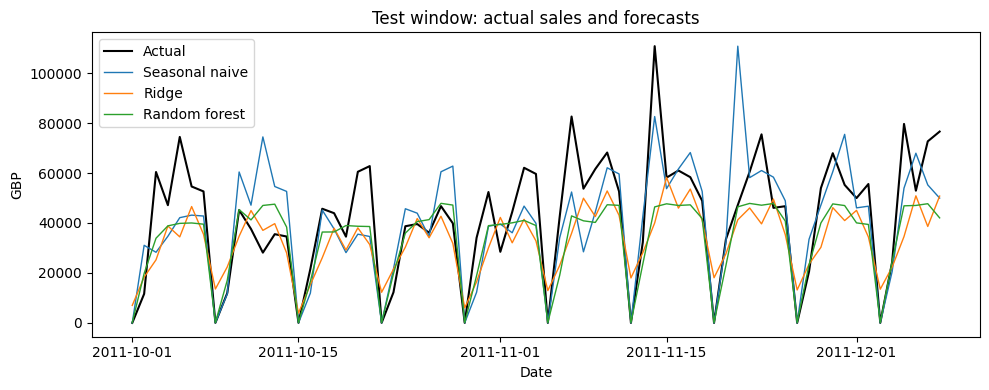

In [6]:
test = result["frames"]["test"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test["date"], test["revenue"], color="black", linewidth=1.5, label="Actual")
for name, model in result["fitted_on_pre_test"].items():
    forecast = model.predict(test[FEATURE_COLUMNS])
    ax.plot(test["date"], forecast, linewidth=1, label=DISPLAY_NAMES[name])
ax.set_title("Test window: actual sales and forecasts")
ax.set_ylabel("GBP")
ax.set_xlabel("Date")
ax.legend()
fig.tight_layout()
plt.show()


## Reading the scores

Use MAE when comparing models. It is the average absolute miss in pounds. RMSE punishes large misses more. R² is higher on the test window than on validation, including for the naive forecast, because the holiday season moves around more. That is not evidence that the pound error got smaller: test MAE is higher than validation MAE for every model.

The saved model is the validation winner, refit through the day before the test window. `train.py` writes it to `models/revenue_model.joblib`. The Streamlit app loads that file and does not apply a separate growth formula.
